# 03 — CLV Modeling: BG/NBD + Gamma-Gamma

**Pipeline:** `01_features` → `02_clv_bgnbd` → **`03_clv_modeling`** → `04_churn` → `05_segmentation` → `06_evaluation`

| | |
|---|---|
| **Depends on** | `feature_table_v2.parquet` (notebook 01) · `clv_bgnbd_params.json` · `clv_gamma_gamma_params.json` |
| **Produces** | Validated 12-month CLV predictions · figures in `docs/figures/` |

---

**Project:** RetentionIQ — Predictive Customer Intelligence for Shopify Brands  
**Owner:** Kimberly (M2)

Fits BG/NBD (purchase frequency + P(alive)) and Gamma-Gamma (expected transaction value) on repeat buyers, combines into a 12-month predicted CLV per customer.

**Scope note:** 87.8% of customers are one-time buyers (`monetary_value = 0`). Gamma-Gamma is fit only on repeat buyers (`frequency > 0 AND monetary_value > 0`). Always state this when reporting CLV figures.

## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Population Scoping](#2-scope)
3. [BG/NBD Fit](#3-bgnbd)
4. [Gamma-Gamma Fit](#4-gg)
5. [12-Month CLV](#5-clv)
6. [Validation Against Team Reference Params](#6-validation)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifetimes import BetaGeoFitter, GammaGammaFitter

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

FEATURES_PATH = "../data/features/feature_table_v2.parquet"

features = pd.read_parquet(FEATURES_PATH)
print(f"Loaded feature table: {features.shape}")
print(f"Columns: {features.columns.tolist()}")

Loaded feature table: (751956, 32)
Columns: ['customer_id', 'frequency', 'recency', 't', 'days_since_last_order', 'monetary_value', 'avg_order_value', 'total_orders', 'total_revenue', 'avg_days_between_orders', 'std_days_between_orders', 'refund_count', 'total_refund_amount', 'refund_rate', 'first_order_date', 'last_order_date', 'is_churned', 'top_product_type', 'price_bucket', 'avg_product_price', 'avg_num_sku_per_order', 'ptype_Combined Collection', 'ptype_Detergent Sheets', 'ptype_Extra Luxe Collection', 'ptype_Shower Steamers', 'ptype_Signature Collection', 'ptype_Towel', 'ptype_unknown', 'pricebucket_budget', 'pricebucket_luxury', 'pricebucket_mid', 'pricebucket_premium']


---
## 2. Population Scoping <a id='2-scope'></a>

BG/NBD models all customers (it handles `frequency = 0`).
Gamma-Gamma requires `frequency > 0 AND monetary_value > 0`.

In [2]:
# ============================================================
# POPULATION SCOPING
# ============================================================
n_total   = len(features)
n_onetime = int((features['monetary_value'] == 0).sum())
repeat    = features[(features['frequency'] > 0) & (features['monetary_value'] > 0)].copy()

print(f"Total customers       : {n_total:,}")
print(f"One-time buyers       : {n_onetime:,}  ({n_onetime/n_total*100:.1f}%)")
print(f"Repeat buyers (GG fit): {len(repeat):,}  ({len(repeat)/n_total*100:.1f}%)")

Total customers       : 751,956
One-time buyers       : 659,934  (87.8%)
Repeat buyers (GG fit): 92,022  (12.2%)


---
## 3. BG/NBD Fit <a id='3-bgnbd'></a>

Fit on the full customer base.

In [3]:
# ============================================================
# FIT BG/NBD (all customers)
# ============================================================
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(features['frequency'], features['recency'], features['t'])

print("BG/NBD fitted parameters:")
print(bgf.summary)

BG/NBD fitted parameters:
        coef  se(coef)  lower 95% bound  upper 95% bound
r     0.0353    0.0002           0.0349           0.0357
alpha 6.7595    0.1198           6.5246           6.9944
a     0.5016    0.0046           0.4925           0.5106
b     0.2094    0.0024           0.2047           0.2142


---
## 4. Gamma-Gamma Fit <a id='4-gg'></a>

Fit only on repeat buyers with positive monetary value.

In [4]:
# ============================================================
# FIT GAMMA-GAMMA (repeat buyers only)
# ============================================================
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat['frequency'], repeat['monetary_value'])

print(f"Gamma-Gamma fitted on {len(repeat):,} repeat buyers:")
print(ggf.summary)

Gamma-Gamma fitted on 92,022 repeat buyers:
    coef  se(coef)  lower 95% bound  upper 95% bound
p 4.0817    0.0167           4.0490           4.1144
q 0.4348    0.0017           0.4316           0.4381
v 3.8700    0.0169           3.8368           3.9031


---
## 5. 12-Month CLV <a id='5-clv'></a>

In [5]:
# ============================================================
# PREDICT 12-MONTH CLV (repeat buyers)
# ============================================================
repeat['predicted_clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    repeat['frequency'], repeat['recency'], repeat['t'], repeat['monetary_value'],
    time=12, freq='D', discount_rate=0.01
).values

print("12-MONTH CLV — repeat buyers only")
print("=" * 45)
print(repeat['predicted_clv_12m'].describe(percentiles=[.5, .9, .95, .99]).to_string())

12-MONTH CLV — repeat buyers only
count   92022.0000
mean       48.9847
std       154.8999
min         0.0000
50%        14.7220
90%       118.3167
95%       202.5265
99%       498.9818
max     18575.7591


### CLV Distribution & Revenue Concentration

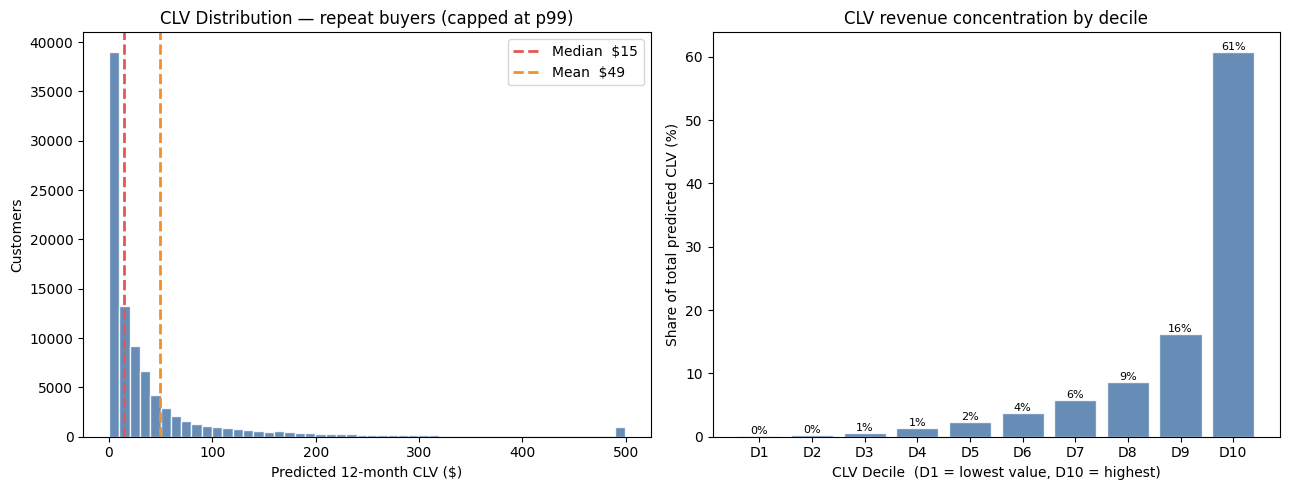

Top decile (D10) holds 61% of total predicted CLV


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- CLV distribution (repeat buyers, capped at p99) ---
cap = repeat['predicted_clv_12m'].quantile(.99)
clv_capped = repeat['predicted_clv_12m'].clip(upper=cap)
axes[0].hist(clv_capped, bins=50, color="#4C78A8", alpha=0.85, edgecolor="white")
axes[0].axvline(repeat['predicted_clv_12m'].median(), color="#E45756", ls="--", lw=2,
                label=f"Median  ${repeat['predicted_clv_12m'].median():.0f}")
axes[0].axvline(repeat['predicted_clv_12m'].mean(), color="#F28E2B", ls="--", lw=2,
                label=f"Mean  ${repeat['predicted_clv_12m'].mean():.0f}")
axes[0].set_xlabel("Predicted 12-month CLV ($)")
axes[0].set_ylabel("Customers")
axes[0].set_title("CLV Distribution — repeat buyers (capped at p99)")
axes[0].legend()

# --- CLV concentration by decile ---
repeat['clv_decile'] = pd.qcut(
    repeat['predicted_clv_12m'], q=10,
    labels=[f"D{i}" for i in range(1, 11)], duplicates="drop"
)
decile_share = (
    repeat.groupby('clv_decile', observed=True)['predicted_clv_12m'].sum()
    / repeat['predicted_clv_12m'].sum() * 100
)
bars = axes[1].bar(decile_share.index, decile_share.values,
                   color="#4C78A8", alpha=0.85, edgecolor="white")
axes[1].set_xlabel("CLV Decile  (D1 = lowest value, D10 = highest)")
axes[1].set_ylabel("Share of total predicted CLV (%)")
axes[1].set_title("CLV revenue concentration by decile")
for bar, v in zip(bars, decile_share.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                 f"{v:.0f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../docs/figures/clv_distribution_deciles.png", dpi=120)
plt.show()
print(f"Top decile (D10) holds {decile_share.iloc[-1]:.0f}% of total predicted CLV")

---
## 6. Validation Against Team Reference Params <a id='6-validation'></a>

Sanity check: our fitted params should match the team's saved reference values.

In [7]:
# ============================================================
# VALIDATION vs data/models/*.json
# ============================================================
ref_b = json.load(open("../data/models/clv_bgnbd_params.json"))
ref_g = json.load(open("../data/models/clv_gamma_gamma_params.json"))

print("BG/NBD — fitted vs reference:")
for k in ['r', 'alpha', 'a', 'b']:
    status = 'MATCH' if abs(bgf.params_[k] - ref_b[k]) < 0.05 else 'DIFF'
    print(f"  {k:<6} mine={bgf.params_[k]:.4f}  ref={ref_b[k]:.4f}  {status}")

print("\nGamma-Gamma — fitted vs reference:")
for k in ['p', 'q', 'v']:
    status = 'MATCH' if abs(ggf.params_[k] - ref_g[k]) < 0.1 else 'DIFF'
    print(f"  {k:<3} mine={ggf.params_[k]:.4f}  ref={ref_g[k]:.4f}  {status}")

BG/NBD — fitted vs reference:
  r      mine=0.0353  ref=0.0353  MATCH
  alpha  mine=6.7595  ref=6.7611  MATCH
  a      mine=0.5016  ref=0.5016  MATCH
  b      mine=0.2094  ref=0.2094  MATCH

Gamma-Gamma — fitted vs reference:
  p   mine=4.0817  ref=4.0817  MATCH
  q   mine=0.4348  ref=0.4348  MATCH
  v   mine=3.8700  ref=3.8700  MATCH


---
## 7. Conclusions <a id='7-conclusions'></a>

In [8]:
# ============================================================
# SUMMARY
# ============================================================
print("=" * 55)
print("  CLV MODELING — SUMMARY (M2)")
print("=" * 55)
print(f"  BG/NBD fit on        : {len(features):,} customers (all)")
print(f"  Gamma-Gamma fit on   : {len(repeat):,} repeat buyers")
print(f"  Median 12m CLV       : ${repeat['predicted_clv_12m'].median():.2f}")
print(f"  Mean 12m CLV         : ${repeat['predicted_clv_12m'].mean():.2f}")
print(f"  P90 12m CLV          : ${repeat['predicted_clv_12m'].quantile(.9):.2f}")
print()
print("  SCOPE: figures describe repeat buyers only (87.8% are one-time).")
print("  NEXT: holdout-control experimental design (Revenue Retained).")

  CLV MODELING — SUMMARY (M2)
  BG/NBD fit on        : 751,956 customers (all)
  Gamma-Gamma fit on   : 92,022 repeat buyers
  Median 12m CLV       : $14.72
  Mean 12m CLV         : $48.98
  P90 12m CLV          : $118.32

  SCOPE: figures describe repeat buyers only (87.8% are one-time).
  NEXT: holdout-control experimental design (Revenue Retained).
